In [29]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import ( Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization,
                                     Input,Rescaling, RandomFlip, RandomRotation, RandomZoom
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from lime import lime_image

In [15]:
DATA_PATH = r"C:\Users\mrtat\Downloads\DL task\dataset\processed_dataset\processed_dataset"
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
# NUM_CLASSES = 4

In [16]:
CT = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_PATH}/CT",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False 
)

CXR = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_PATH}/CXR",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

Cough_sound = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_PATH}/Cough sound",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

Found 2000 files belonging to 4 classes.
Found 2000 files belonging to 4 classes.
Found 2000 files belonging to 4 classes.


In [17]:
# --- 1. Helper: efficient conversion from TF Dataset to NumPy ---
def ds_to_numpy(dataset):
    """Extracts images and labels from a TF dataset into NumPy arrays."""
    # .as_numpy_iterator() is faster and memory efficient
    images = np.concatenate(list(dataset.map(lambda x, y: x).as_numpy_iterator()))
    labels = np.concatenate(list(dataset.map(lambda x, y: y).as_numpy_iterator()))
    return images, labels

# --- 2. Extract Data ---
print("Extracting and merging modalities...")
# We only need labels from one dataset since they should be identical
X_ct, y_all    = ds_to_numpy(CT)
X_cxr, _       = ds_to_numpy(CXR)
X_cough, _     = ds_to_numpy(Cough_sound)

# --- 3. Merge Modalities ---
# Concatenate along the channel axis (last axis)
# Shape becomes: (N, 64, 64, 9)
X_combined = np.concatenate([X_ct, X_cxr, X_cough], axis=-1)

# --- 4. Stratified Split (80% Train, 10% Val, 10% Test) ---
# Step 1: Split 80% Train, 20% Temp (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_combined, y_all, test_size=0.2, stratify=y_all, random_state=42
)

# Step 2: Split the 20% Temp into equal halves (10% Val, 10% Test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# --- 5. Convert back to optimized TF Datasets ---
def create_tf_ds(x, y, batch_size=32, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(x))
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = create_tf_ds(X_train, y_train, shuffle=True)
val_ds   = create_tf_ds(X_val, y_val, shuffle=False)
test_ds  = create_tf_ds(X_test, y_test, shuffle=False)

print(f"Data ready! Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Extracting and merging modalities...
Data ready! Train: (1600, 128, 128, 9), Val: (200, 128, 128, 9), Test: (200, 128, 128, 9)


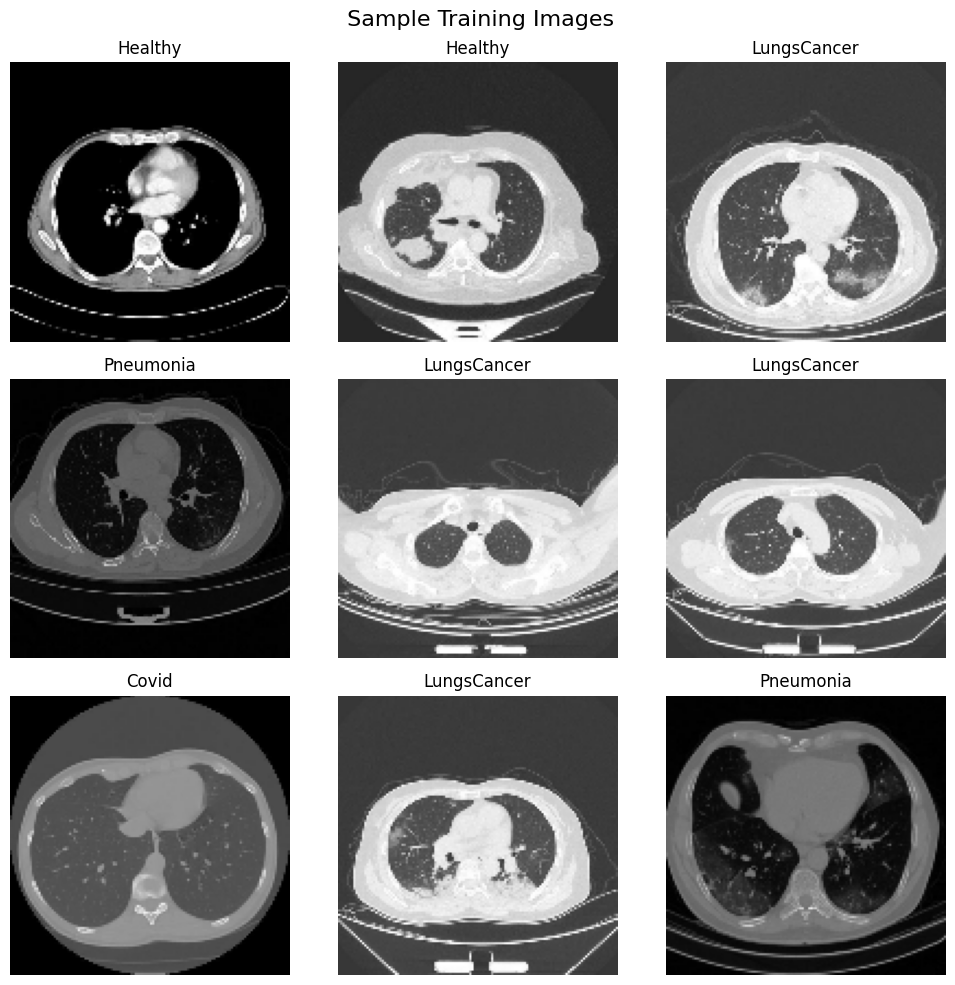

In [18]:
images, labels = next(iter(train_ds))
class_names = ["Covid", "Healthy", "LungsCancer", "Pneumonia"]

num_images = min(9, images.shape[0])

plt.figure(figsize=(10, 10))
for i in range(num_images):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i, :, :, :3].numpy().astype("uint8"))
    class_index = tf.argmax(labels[i]).numpy()
    plt.title(class_names[class_index])
    plt.axis("off")

plt.suptitle(" Sample Training Images", fontsize=16)
plt.tight_layout()
plt.show()


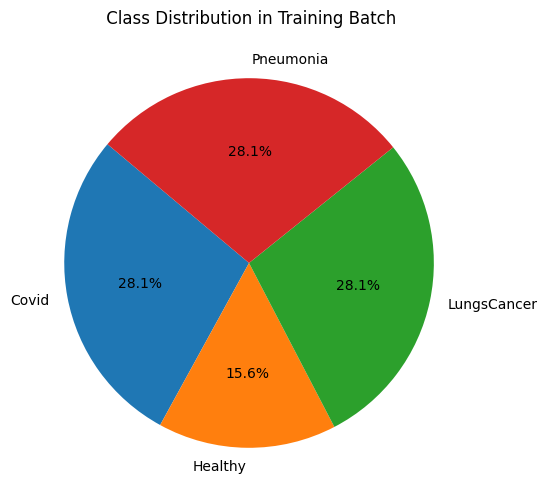

In [19]:
label_indices = tf.argmax(labels, axis=1).numpy()
counts = [np.sum(label_indices == i) for i in range(len(class_names))]

plt.figure(figsize=(6, 6))
plt.pie(counts, labels=class_names, autopct='%1.1f%%', startangle=140)
plt.title(" Class Distribution in Training Batch")
plt.show()

In [20]:
def build_model():
    model = Sequential([


        # --- Convolutional layers ---
        Conv2D(32, (3,3), activation='relu', padding='same',input_shape=(128, 128, 9)), # 9 channels for 3 modalities (As you said in Youtube video)
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        # --- Flatten and Dense layers ---
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.2),
        Dense(4, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',  # Use categorical crossentropy for class classification
                  metrics=['accuracy'])
    return model


In [21]:
model=build_model()
model.summary()

c:\Users\mrtat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,485,764 (32.37 MB)

 Trainable params: 8,485,316 (32.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [22]:


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1 
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop, checkpoint],
    verbose=1
)




Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 926ms/step - accuracy: 0.7615 - loss: 4.6356
Epoch 1: val_loss improved from None to 19.12686, saving model to best_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 53s 977ms/step - accuracy: 0.8450 - loss: 2.5072 - val_accuracy: 0.5200 - val_loss: 19.1269
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 942ms/step - accuracy: 0.9281 - loss: 0.4218
Epoch 2: val_loss improved from 19.12686 to 1.93491, saving model to best_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 49s 973ms/step - accuracy: 0.9275 - loss: 0.4435 - val_accuracy: 0.8000 - val_loss: 1.9349
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 907ms/step - accuracy: 0.9436 - loss: 0.2651
Epoch 3: val_loss improved from 1.93491 to 0.36946, saving model to best_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 47s 939ms/step - accuracy: 0.9469 - loss: 0.3177 - val_accuracy: 0.9250 - val_loss: 0.3695
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step - accuracy: 0.9673 - loss: 0.1078
Epoch 4: val_loss improved from 0.36946 to 0.36

In [34]:
# --- Evaluate on test set ---
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")
print(f"🧮 Test Loss: {test_loss:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.9200 - loss: 0.4137

✅ Test Accuracy: 0.9200
🧮 Test Loss: 0.4137


Text(0.5, 1.0, 'Model Loss')

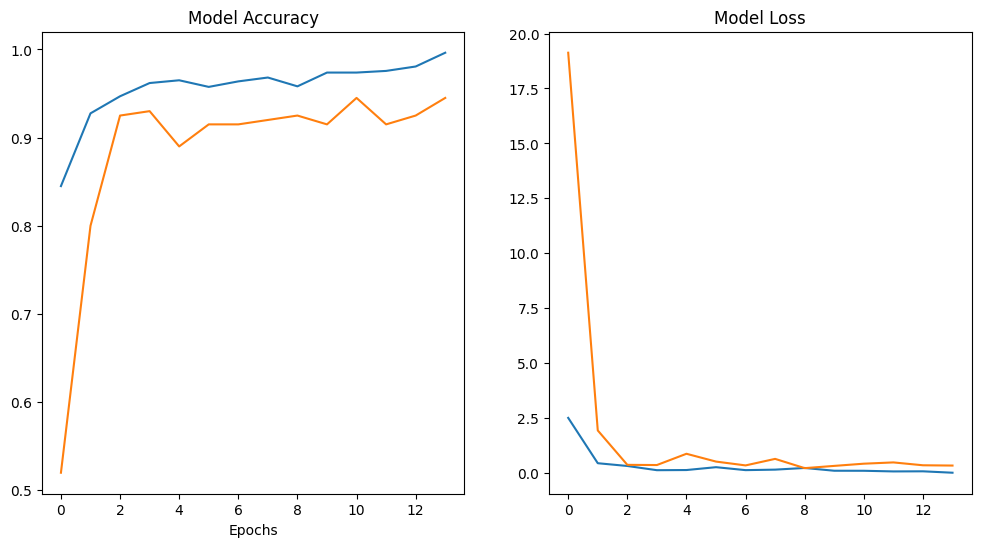

In [35]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')

In [37]:
# Get true labels and predictions
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred = model.predict(test_ds)


y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_true, axis=1)

# --- Classification report ---
print("\n📋 Classification Report:\n")
print(classification_report(y_true, y_pred_classes, digits=4))



7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step

📋 Classification Report:

              precision    recall  f1-score   support

           0     0.8136    0.9600    0.8807        50
           1     0.9434    1.0000    0.9709        50
           2     1.0000    0.9600    0.9796        50
           3     0.9500    0.7600    0.8444        50

    accuracy                         0.9200       200
   macro avg     0.9267    0.9200    0.9189       200
weighted avg     0.9267    0.9200    0.9189       200



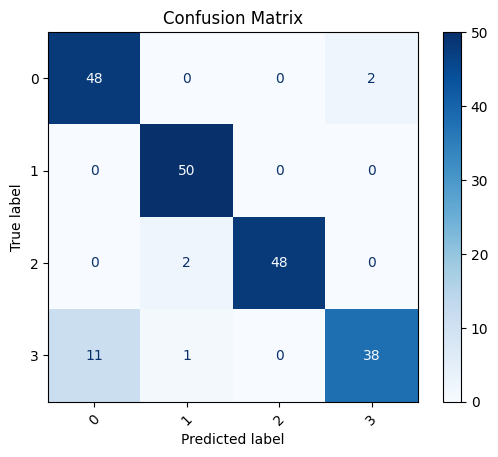

In [38]:
# --- Confusion matrix ---
cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()
